#### 1. Import the Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

#### 2. Load the Dataset

##### ."If there are escape sequences or non-ascii characters in the text, decode them into proper Unicode characters instead of throwing an error."
##### s = b'Price: \\u20B9 500'   # raw bytes with escape sequence for ₹
##### print(s.decode('unicode_escape')) output-> 500


In [2]:

df = pd.read_csv('Diwali Sales Data.csv', encoding= 'unicode_escape')
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN


#### 3. Understanding the Dataset

In [3]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount', 'Status', 'unnamed1'],
      dtype='object')

In [4]:
df.shape

(11251, 15)

In [5]:
df.head(30)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.00,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.00,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.00,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.00,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.00,NaN,NaN
5,1000588,Joni,P00057942,M,26-35,28,1,Himachal Pradesh,Northern,Food Processing,Auto,1,23877.00,NaN,NaN
6,1001132,Balk,P00018042,F,18-25,25,1,Uttar Pradesh,Central,Lawyer,Auto,4,23841.00,NaN,NaN
7,1002092,Shivangi,P00273442,F,55+,61,0,Maharashtra,Western,IT Sector,Auto,1,NaN,NaN,NaN
8,1003224,Kushal,P00205642,M,26-35,35,0,Uttar Pradesh,Central,Govt,Auto,2,23809.00,NaN,NaN
9,1003650,Ginny,P00031142,F,26-35,26,1,Andhra Pradesh,Southern,Media,Auto,4,23799.99,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [7]:
df['Product_Category'].unique()

array(['Auto', 'Hand & Power Tools', 'Stationery', 'Tupperware',
       'Footwear & Shoes', 'Furniture', 'Food', 'Games & Toys',
       'Sports Products', 'Books', 'Electronics & Gadgets', 'Decor',
       'Clothing & Apparel', 'Beauty', 'Household items', 'Pet Care',
       'Veterinary', 'Office'], dtype=object)

In [8]:
df['Occupation'].unique()

array(['Healthcare', 'Govt', 'Automobile', 'Construction',
       'Food Processing', 'Lawyer', 'IT Sector', 'Media', 'Banking',
       'Retail', 'Hospitality', 'Aviation', 'Agriculture', 'Textile',
       'Chemical'], dtype=object)

#### 4. Data Cleaning

In [9]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
11246    False
11247    False
11248    False
11249    False
11250    False
Length: 11251, dtype: bool

In [10]:
df.duplicated().any()

True

In [11]:
df.duplicated().sum()

8

In [12]:
df = df.drop_duplicates(keep='last')
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN


In [13]:
df.shape

(11243, 15)

In [14]:
#check for null values
# pd.isnull(df).sum()
df.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11243
unnamed1            11243
dtype: int64

In [15]:
df = df.dropna(subset=['Amount'])
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN


In [16]:
df.shape

(11231, 15)

##### 5. Data Transformation

In [17]:
#drop unrelated/blank columns
df = df.drop(columns = ['Status', 'unnamed1'], axis=1)
df

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0


In [18]:
df['Amount'].dtypes

dtype('float64')

In [19]:
df['Amount'] = df['Amount'].astype('int')

In [20]:
df['Amount'].dtypes

dtype('int32')

In [21]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [22]:
df['Marital_Status']=df['Marital_Status'].map({0:'Married',1:'Unmarried'})

In [23]:
df.describe()

,User_ID,Age,Orders,Amount
count,1.123100e+04,11231.000000,11231.000000,11231.000000
mean,1.003004e+06,35.411985,2.489093,9454.084676
std,1.716055e+03,12.756116,1.114880,5221.728074
min,1.000001e+06,12.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,2.000000,5443.000000
50%,1.003065e+06,33.000000,2.000000,8109.000000
75%,1.004428e+06,43.000000,3.000000,12677.500000
max,1.006040e+06,92.000000,4.000000,23952.000000


In [24]:
# use describe() for specific columns
df[['Age', 'Orders', 'Amount']].describe()

,Age,Orders,Amount
count,11231.000000,11231.000000,11231.000000
mean,35.411985,2.489093,9454.084676
std,12.756116,1.114880,5221.728074
min,12.000000,1.000000,188.000000
25%,27.000000,2.000000,5443.000000
50%,33.000000,2.000000,8109.000000
75%,43.000000,3.000000,12677.500000
max,92.000000,4.000000,23952.000000


# Exploratory Data Analysis(Descriptive)

##### 1. What is the total revenue generated during the Diwali sales?

In [25]:
df['Amount'].sum()

106178825

*Observation: Diwali sales brought in a substantial revenue across all states*

##### 2. Which gender contributed more to overall sales amount

In [26]:
df.groupby('Gender')['Amount'].sum()

Gender
F    74307679
M    31871146
Name: Amount, dtype: int32

*Females contributed more than males.*

##### 3.Which age group spent the most during Diwali sales

In [27]:
df.groupby('Age Group')['Amount'].sum()

Age Group
0-17      2699653
18-25    17235530
26-35    42581767
36-45    22135135
46-50     9207844
51-55     8237909
55+       4080987
Name: Amount, dtype: int32

*26–35 years age group spent the most.*

##### 4. Which state contributed the highest sales

In [28]:
df.groupby('State')['Amount'].sum().sort_values(ascending=False)


State
Uttar Pradesh       19346055
Maharashtra         14404467
Karnataka           13523540
Delhi               11603818
Madhya Pradesh       8101142
Andhra Pradesh       8037146
Himachal Pradesh     4963368
Haryana              4217871
Bihar                4014669
Gujarat              3938159
Kerala               3894491
Jharkhand            3026456
Uttarakhand          2520944
Rajasthan            1909409
Punjab               1525800
Telangana            1151490
Name: Amount, dtype: int32

*Uttar Pradesh, followed by Maharashtra and Karnataka.*

##### 5. Which state had the highest number of orders

In [29]:
df.groupby('State')['Orders'].count().sort_values(ascending=False)


State
Uttar Pradesh       1942
Maharashtra         1522
Karnataka           1304
Delhi               1104
Madhya Pradesh       921
Andhra Pradesh       811
Himachal Pradesh     608
Kerala               453
Haryana              451
Bihar                433
Gujarat              426
Jharkhand            380
Uttarakhand          320
Rajasthan            231
Punjab               200
Telangana            125
Name: Orders, dtype: int64

*Uttar Pradesh leads in number of orders.*

##### 6. Which occupation category spent the most

In [30]:
df.groupby('Occupation')['Amount'].sum().sort_values(ascending=False)


Occupation
IT Sector          14741862
Healthcare         13034586
Aviation           12599994
Banking            10770610
Govt                8517212
Hospitality         6337633
Media               6295832
Automobile          5368596
Chemical            5297436
Lawyer              4981665
Retail              4783170
Food Processing     4070670
Construction        3589588
Textile             3204972
Agriculture         2584999
Name: Amount, dtype: int32

*Healthcare and IT professionals spent the most.*

##### 7. Most frequently purchased product category

In [31]:
df['Product_Category'].value_counts()


Product_Category
Clothing & Apparel       2653
Food                     2490
Electronics & Gadgets    2082
Footwear & Shoes         1059
Household items           520
Beauty                    422
Games & Toys              386
Sports Products           356
Furniture                 352
Pet Care                  212
Office                    113
Stationery                112
Books                     103
Decor                      96
Auto                       96
Veterinary                 81
Tupperware                 72
Hand & Power Tools         26
Name: count, dtype: int64

*Clothing & Apparel.*

##### 8. Who purchased more – Married or Unmarried people

In [32]:
df.groupby('Marital_Status')['Amount'].sum()

Marital_Status
Married      62098734
Unmarried    44080091
Name: Amount, dtype: int32

*Married customers purchased more than unmarried.*

##### 9. Which age group ordered the maximum number of products

In [33]:
df.groupby('Age Group')['Orders'].count().idxmax


<bound method Series.idxmax of Age Group
0-17      296
18-25    1878
26-35    4536
36-45    2282
46-50     983
51-55     829
55+       427
Name: Orders, dtype: int64>

*26–35 years*

##### 10. Average order amount during Diwali sales

In [34]:
df['Amount'].mean()


9454.084676342267

*Average purchase value indicates a mid-to-high range of festive shopping.*

# Exploratory Data Analysis(Visuals)

##### 1.Gender vs Sales Amount

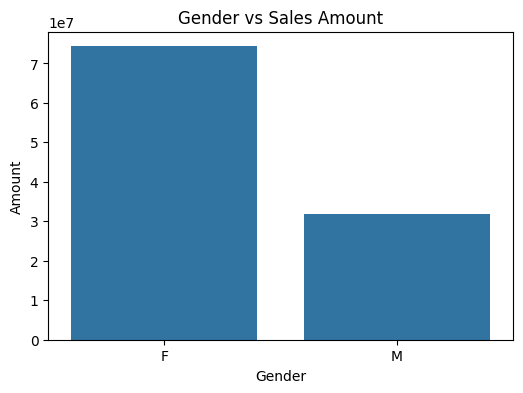

Observation: Females contributed more to sales than males.


In [35]:
gender_sales = df.groupby('Gender')['Amount'].sum().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(x='Gender', y='Amount', data=gender_sales)
plt.title('Gender vs Sales Amount')
plt.show()
print("Observation: Females contributed more to sales than males.")

##### 2.Age Group vs Total Sales

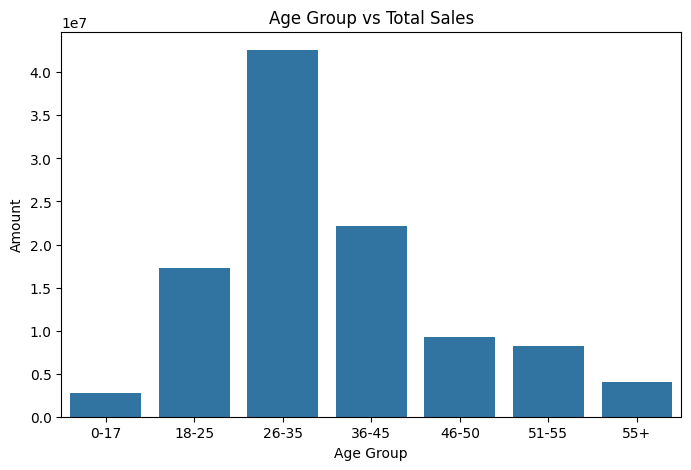

Observation: 26–35 age group spent the most.


In [36]:
age_sales = df.groupby('Age Group')['Amount'].sum().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='Age Group', y='Amount', data=age_sales)
plt.title('Age Group vs Total Sales')
plt.show()
print("Observation: 26–35 age group spent the most.")

##### 3.Top 10 States by Total Sales

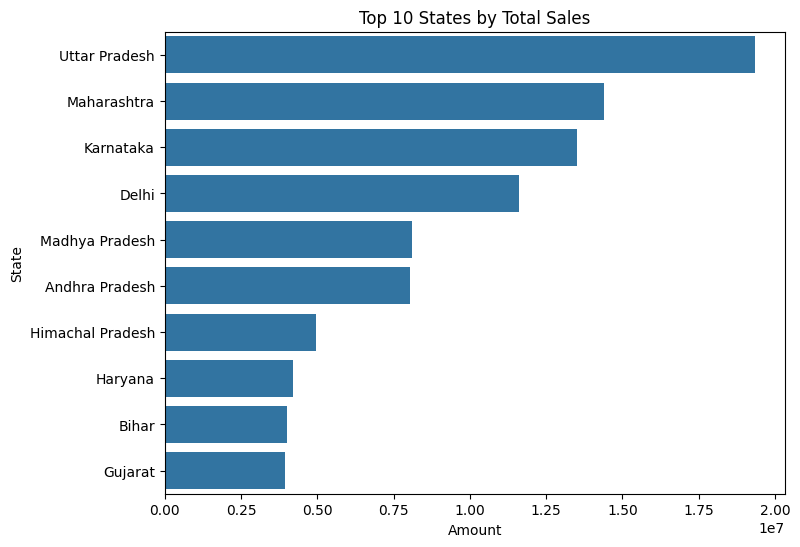

Observation: UP, Maharashtra, Karnataka lead in total sales.


In [37]:
state_sales = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(8,6))
sns.barplot(x='Amount', y='State', data=state_sales)
plt.title('Top 10 States by Total Sales')
plt.show()
print("Observation: UP, Maharashtra, Karnataka lead in total sales.")

##### 4. Top 10 States by Number of Orders

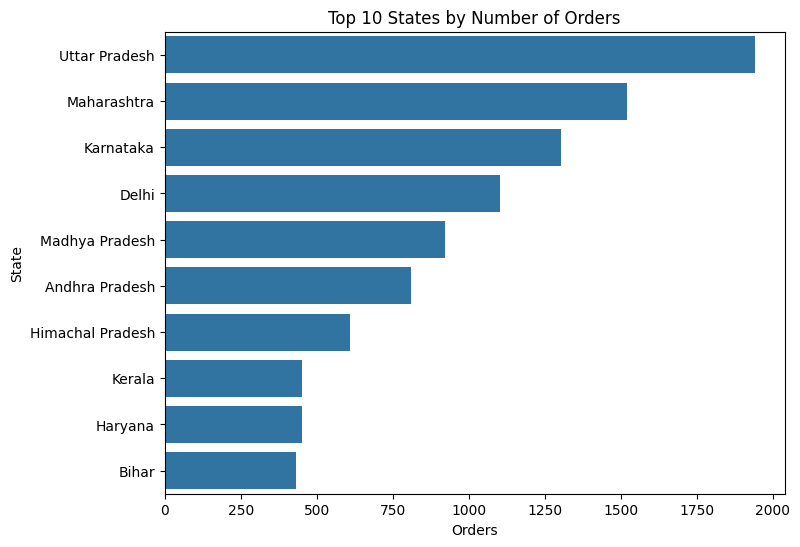

Observation: UP dominate in number of orders.


In [38]:
state_orders = df.groupby('State')['Orders'].count().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(8,6))
sns.barplot(x='Orders', y='State', data=state_orders)
plt.title('Top 10 States by Number of Orders')
plt.show()
print("Observation: UP dominate in number of orders.")

##### 5.Occupation vs Total Sales

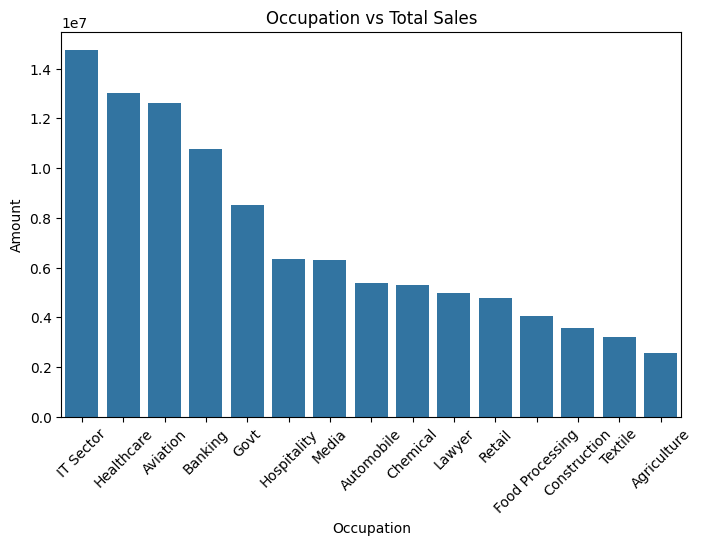

Observation: IT & Healthcare professionals spent the most.


In [39]:
occupation_sales = df.groupby('Occupation')['Amount'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='Occupation', y='Amount', data=occupation_sales)
plt.title('Occupation vs Total Sales')
plt.xticks(rotation=45)
plt.show()
print("Observation: IT & Healthcare professionals spent the most.")

##### 6. Marital Status vs Sales Amount

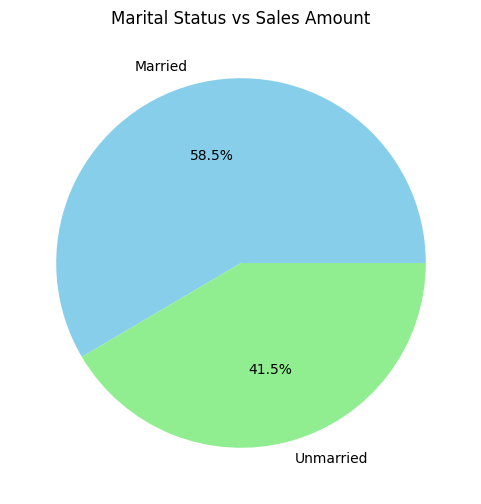

Observation: Married customers purchased more than unmarried ones.


In [40]:
marital_sales = df.groupby('Marital_Status')['Amount'].sum()
plt.figure(figsize=(6,6))
marital_sales.plot.pie(autopct='%1.1f%%', colors=['skyblue','lightgreen'])
plt.title('Marital Status vs Sales Amount')
plt.ylabel('')
plt.show()
print("Observation: Married customers purchased more than unmarried ones.")

##### 7. Product Category Distribution

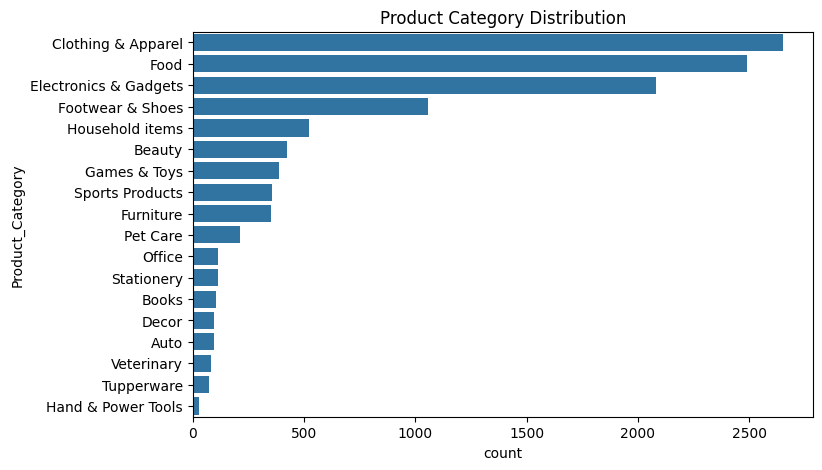

Observation: Clothing & Apparel had the highest orders.


In [41]:
plt.figure(figsize=(8,5))
sns.countplot(y='Product_Category', data=df, order=df['Product_Category'].value_counts().index)
plt.title('Product Category Distribution')
plt.show()
print("Observation: Clothing & Apparel had the highest orders.")

##### 8. Occupation vs Average Order Value

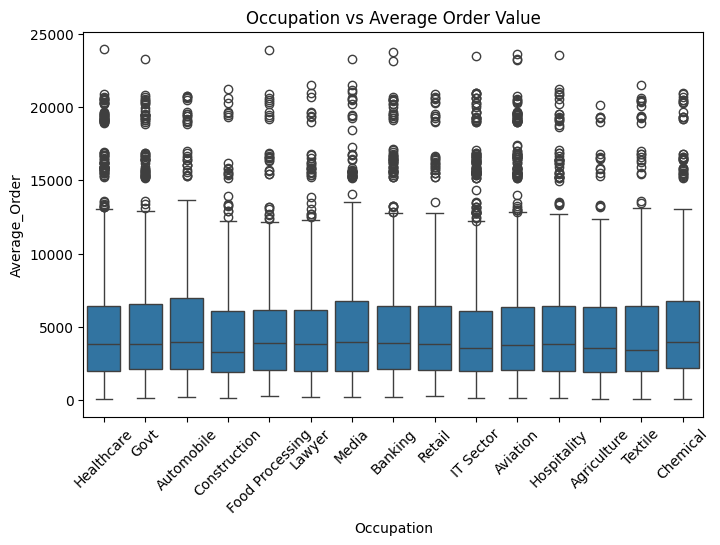

Observation:Healthcare,Aviation customers buy higher-value products.


In [42]:
df['Average_Order'] = df['Amount'] / df['Orders']
plt.figure(figsize=(8,5))
sns.boxplot(x='Occupation', y='Average_Order', data=df)
plt.title('Occupation vs Average Order Value')
plt.xticks(rotation=45)
plt.show()
print("Observation:Healthcare,Aviation customers buy higher-value products.")

##### 9.Age Group vs Number of Orders split by Gender

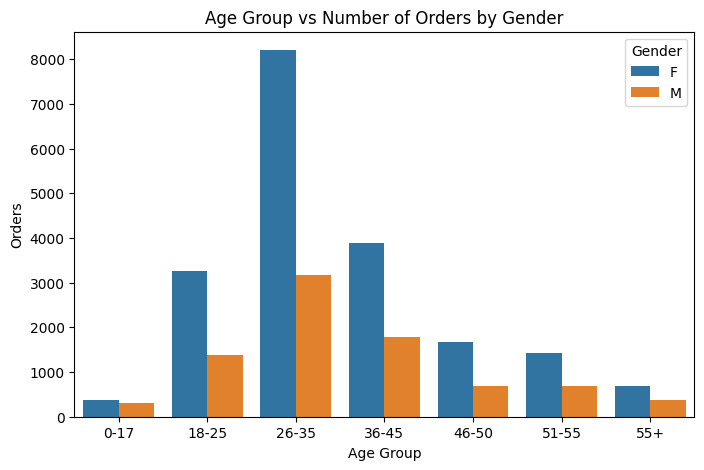

Observation: Females in 26–35 group placed the maximum orders.


In [43]:
age_gender_orders = df.groupby(['Age Group','Gender'])['Orders'].sum().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='Age Group', y='Orders', hue='Gender', data=age_gender_orders)
plt.title('Age Group vs Number of Orders by Gender')
plt.show()
print("Observation: Females in 26–35 group placed the maximum orders.")

## Conclusion:

### 

Diwali sales were primarily driven by females aged 26–35 years.

North & Western India (UP, Maharashtra, Karnataka) emerged as the biggest markets.

Married people with professional occupations showed higher purchasing power.

Product demand concentrated on Clothing, Apparel, and Electronics.

Future sales strategies can focus on working women in metro cities to maximize revenue.